In [1]:
import json
import os
try:
    from backend.utils import load_json
except ModuleNotFoundError:
    print("Updating working directory....")
    os.chdir("../")
    # print(os.getcwd())
    from backend.utils import load_json
    
from tqdm import tqdm 
from backend.utils import load_response_dict
from backend.dataset_utils import organize_dataset
from backend.nli_labels import ExNLILabel
import math

import matplotlib.pyplot as plt
import numpy as np

from backend.uncertainty.utils import remove_invalid, calculate_probs, find_relevant_logprobs, sort_correct_wrong
from backend.uncertainty.metrics import calculate_uncertainty
import itertools

Updating working directory....


In [2]:
# load dataset
dataset = load_json("data/test.json")
dataset = organize_dataset(dataset)

response_dirs = {
    "Qwen3 30B": [[
        "out/responses/config_1/qwen3_30b/narendra_nli_nonbinary/seed0",
        "out/responses/config_1/qwen3_30b/narendra_nli_nonbinary/seed1",
        "out/responses/config_1/qwen3_30b/narendra_nli_nonbinary/seed42"
    ], "classification"],
    "Gemma3 27B": [[
        "out/responses/config_1/gemma3_27b/narendra_nli_nonbinary/seed0",
        "out/responses/config_1/gemma3_27b/narendra_nli_nonbinary/seed1",
        "out/responses/config_1/gemma3_27b/narendra_nli_nonbinary/seed42"
    ], "classification"],
    "GPT-OSS 20B": [[
        "out/responses/config_1/gpt-oss_20b/narendra_nli_nonbinary/seed0",
        "out/responses/config_1/gpt-oss_20b/narendra_nli_nonbinary/seed1",
        "out/responses/config_1/gpt-oss_20b/narendra_nli_nonbinary/seed42"
    ], None],
    "LLaMA3.1 8B": [[
        "out/responses/config_1/llama3.1_8b/narendra_nli_nonbinary/seed0",
        "out/responses/config_1/llama3.1_8b/narendra_nli_nonbinary/seed1",
        "out/responses/config_1/llama3.1_8b/narendra_nli_nonbinary/seed42"
    ], "classification"]
}

    # load and process responses

model_responses = {}
by_seed = {}
for model, (response_dir, structure) in response_dirs.items():
    by_seed[model] = {}
    correct, wrong = {}, {}
    for fp in response_dir:
        try:
            responses = load_response_dict(fp)
        except FileNotFoundError:
            continue
        remove_invalid(responses)

        # add probabilities to responses
        # calculate_probs(responses)
        find_relevant_logprobs(responses, relevant_scope=None, structure=structure)
        calculate_uncertainty(responses)

        # find correct/wrong
        c, w = sort_correct_wrong(dataset, responses)

        # complicated indexing to save on boilerplating 
        for big_dict, sub_dict in [(correct, c), (wrong, w)]:
            if len(big_dict) == 0:
                for k,v in sub_dict.items():
                    big_dict[k] = v
            else:
                for k,v in big_dict.items():
                    big_dict[k] = v + sub_dict[k]
        
        seed = int(fp.split("/")[-1][4:])
        by_seed[model][seed] = {
            "correct": c,
            "wrong": w
        }
    
    model_responses[model] = {
        "correct": correct,
        "wrong": wrong
    }

Loading responses: 100%|██████████| 123/123 [01:02<00:00,  1.98it/s]


Removed 3 invalid answers!


Probabilities:  17%|█▋        | 21/123 [00:02<00:09, 11.09it/s]/home/baratovfs/repos/contractnli-llms/backend/uncertainty/metrics.py:14: RuntimeWarning: overflow encountered in exp
  return np.exp(average_logprob(logprobs))
Sorting: 100%|██████████| 123/123 [00:00<00:00, 42587.04it/s]


Num correct: 1536
Num wrong:   552


Loading responses: 100%|██████████| 123/123 [00:42<00:00,  2.93it/s]


...

Num correct: 1021
Num wrong:   1070


Loading responses: 100%|██████████| 123/123 [00:05<00:00, 21.66it/s]


Removed 0 invalid answers!


Sorting: 100%|██████████| 123/123 [00:00<00:00, 57545.94it/s]

Num correct: 959
Num wrong:   1132


In [21]:
def set_boxplot_line_color(bp, color, width=2.):
    for element in ['boxes', 'whiskers', 'caps', 'medians']:
        for item in bp[element]:
            item.set_color(color)
            item.set_linewidth(width)

def big_boxplot(correct: dict, wrong: dict, save_file: str, metric: str, title: str = ""):

    classes = sorted(list(correct.keys()))

    correct_data = []
    wrong_data = []
    for k in classes:
        correct_data.append(correct[k])
        wrong_data.append(wrong[k])

    num_groups = len(classes)
    positions = np.arange(num_groups)

    offset = 0.15
    width = 0.2
    
    fig = plt.figure(figsize=(10,7))
    ax = plt.gca()

    
    bp_correct = plt.boxplot(
        correct_data,
        positions=positions - offset,
        widths=width,
        patch_artist=False,
        showfliers=False
    )

    bp_wrong = plt.boxplot(
        wrong_data,
        positions=positions + offset,
        widths=width,
        patch_artist=False,
        showfliers=False
    )

    # Color the boxes
    set_boxplot_line_color(bp_correct, "blue")
    set_boxplot_line_color(bp_wrong, "red")

    # Axis formatting
    plt.xticks(positions, classes)
    plt.ylabel(metric)
    plt.legend(
        [bp_correct['boxes'][0], bp_wrong['boxes'][0]],
        ['Correct', 'Wrong']
    )
    
    ax.set_xlabel("Response prediction")
    ax.set_title(title)

    return ax, fig

    
# pick model
sorted_model_responses = {}
for k,v in model_responses.items():
    sorted_model_responses[k] = {}

    model_dict = model_responses[k]

    # sort correct/wrong properly, by class
    correct = {}
    wrong = {}
    for cw_dict, cw_str in [[correct, "correct"], [wrong, "wrong"]]:
        ld = model_dict[cw_str]
        for label in ld.keys():
            if label not in cw_dict:
                cw_dict[label] = []
            for el in ld[label]:
                cw_dict[label] += [el["uncertainty"]["perplexity"]]

        sorted_model_responses[k][cw_str] = cw_dict
    
# # plot graph
# ax, fig = boxplot_analysis(correct, wrong, metric="Perplexity", title=f"Perplexity for GPT-OSS 20B", save_file=None)
# fig.show()

In [4]:
def big_boxplot(correct: dict, wrong: dict, save_file: str, metric: str, title: str = ""):

    classes = sorted(list(correct.keys()))

    correct_data = []
    wrong_data = []
    for k in classes:
        correct_data.append(correct[k])
        wrong_data.append(wrong[k])

    num_groups = len(classes)
    positions = np.arange(num_groups)

    offset = 0.15
    width = 0.2
    
    fig = plt.figure(figsize=(10,7))
    ax = plt.gca()

    
    bp_correct = plt.boxplot(
        correct_data,
        positions=positions - offset,
        widths=width,
        patch_artist=False,
        showfliers=False
    )

    bp_wrong = plt.boxplot(
        wrong_data,
        positions=positions + offset,
        widths=width,
        patch_artist=False,
        showfliers=False
    )

    # Color the boxes
    set_boxplot_line_color(bp_correct, "blue")
    set_boxplot_line_color(bp_wrong, "red")

    # Axis formatting
    plt.xticks(positions, classes)
    plt.ylabel(metric)
    plt.legend(
        [bp_correct['boxes'][0], bp_wrong['boxes'][0]],
        ['Correct', 'Wrong']
    )
    
    ax.set_xlabel("Response prediction")
    ax.set_title(title)

    return ax, fig




In [5]:

def plot_model_grouped_boxplots(data):
    """
    Parameters
    ----------
    data : dict
        {
            "model1": {
                "correct": {"label1": [...], "label2": [...], "label3": [...]},
                "wrong":   {"label1": [...], "label2": [...], "label3": [...]}
            },
            "model2": { ... }
        }
    """

    models = list(data.keys())
    labels = list(next(iter(data.values()))['correct'].keys())

    num_labels = len(labels)
    box_width = 0.3
    pair_offset = 0.2
    model_gap = 1.0

    fig, ax = plt.subplots(figsize=(20,7))

    x_positions = []
    x_labels = []
    model_centers = []

    current_x = 0

    for model in models:
        model_start = current_x

        for label in labels:
            correct_vals = data[model]['correct'][label]
            wrong_vals = data[model]['wrong'][label]

            pos_correct = current_x - pair_offset
            pos_wrong = current_x + pair_offset

            bp_correct = ax.boxplot(
                correct_vals,
                positions=[pos_correct],
                widths=box_width,
                patch_artist=False,
                showfliers=False
            )
            bp_wrong = ax.boxplot(
                wrong_vals,
                positions=[pos_wrong],
                widths=box_width,
                patch_artist=False,
                showfliers=False
            )

            set_boxplot_line_color(bp_correct, 'blue')
            set_boxplot_line_color(bp_wrong, 'red')

            x_positions.append(current_x)
            x_labels.append(label)

            current_x += 1

        model_end = current_x - 1
        model_centers.append((model_start + model_end) / 2)
        current_x += model_gap

    # Label ticks for individual label pairs
    ax.set_xticks(x_positions)
    ax.set_xticklabels(x_labels)

    # Model labels below x-axis
    for center, model in zip(model_centers, models):
        ax.text(
            center,
            -0.05,
            model,
            ha='center',
            va='top',
            transform=ax.get_xaxis_transform(),
            fontsize=10,
            fontweight='bold'
        )

    ax.set_ylabel("Value")

    # Legend
    ax.plot([], [], color='blue', label='correct')
    ax.plot([], [], color='red', label='wrong')
    ax.legend()

    plt.tight_layout()
    plt.show()

    return fig, ax

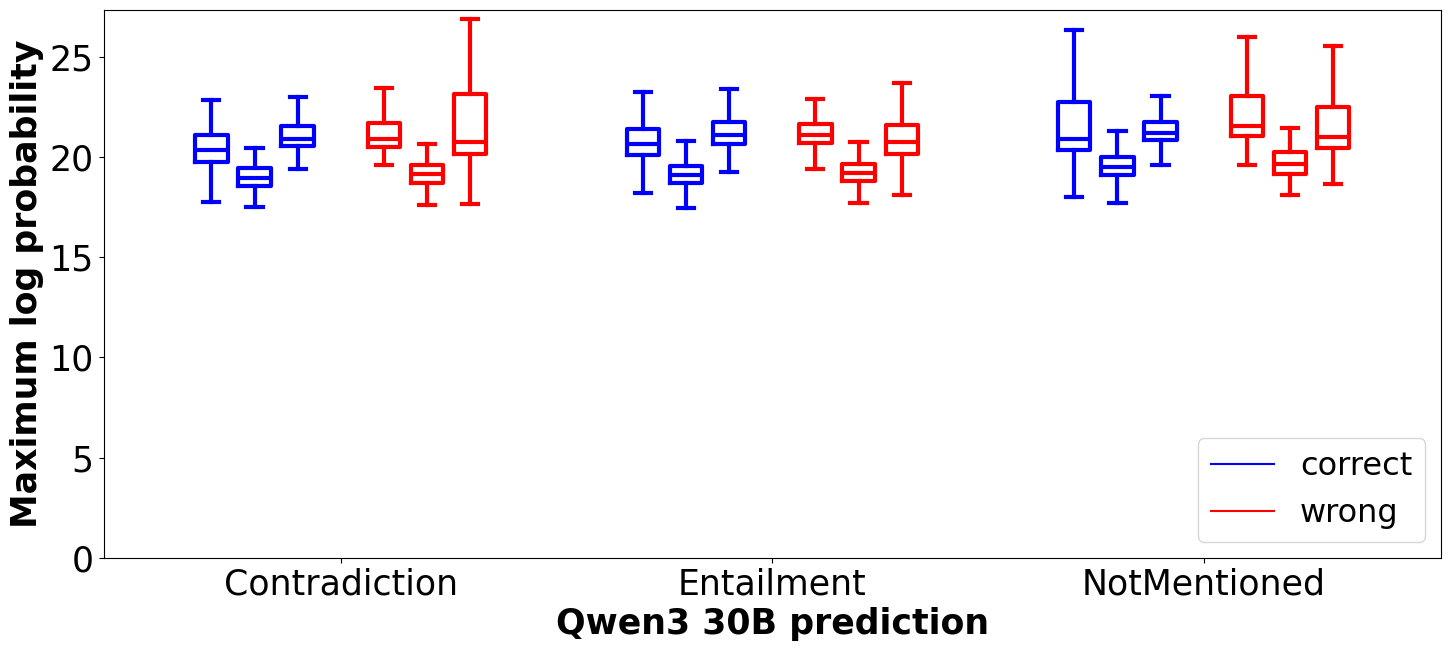

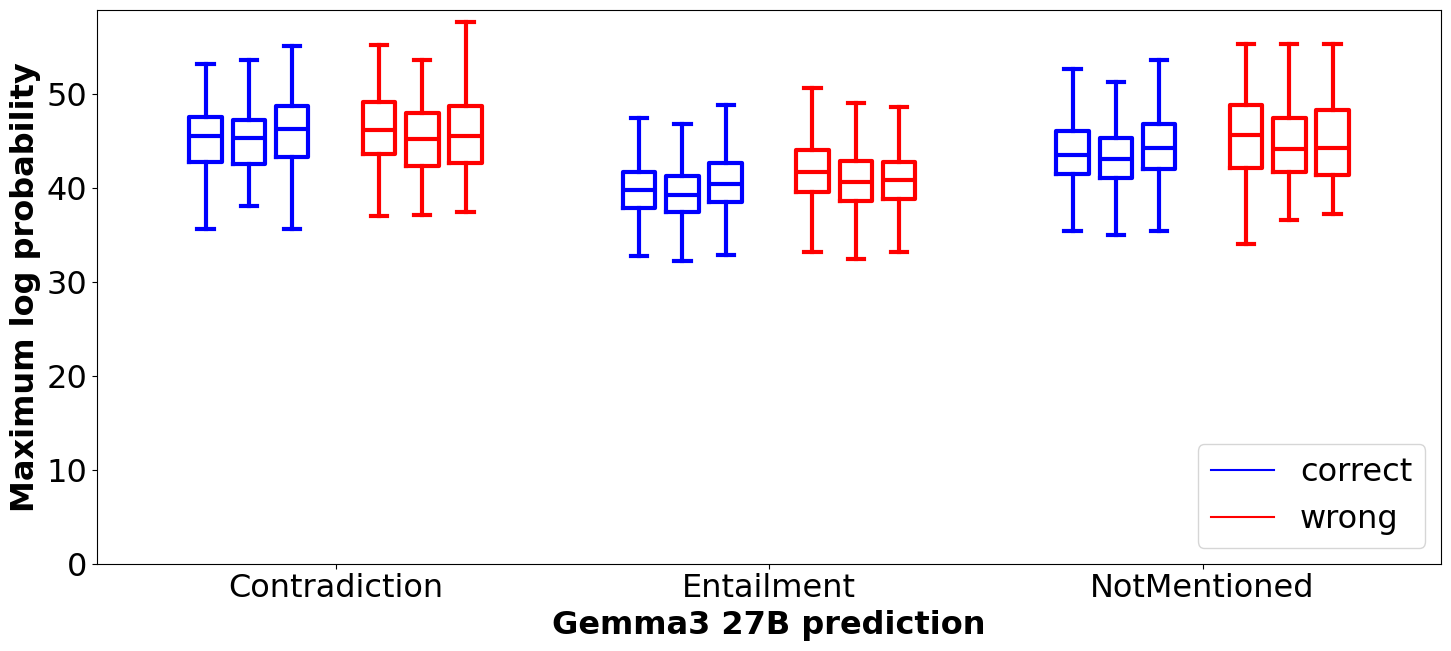

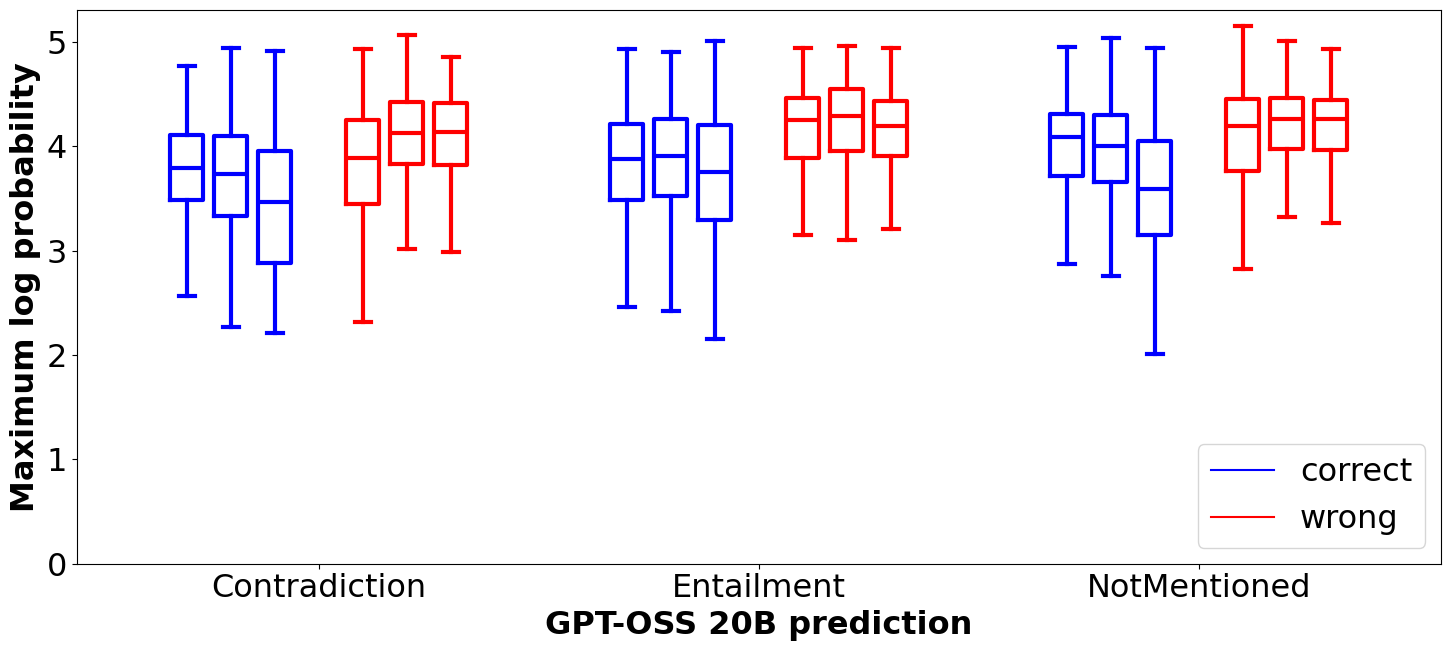

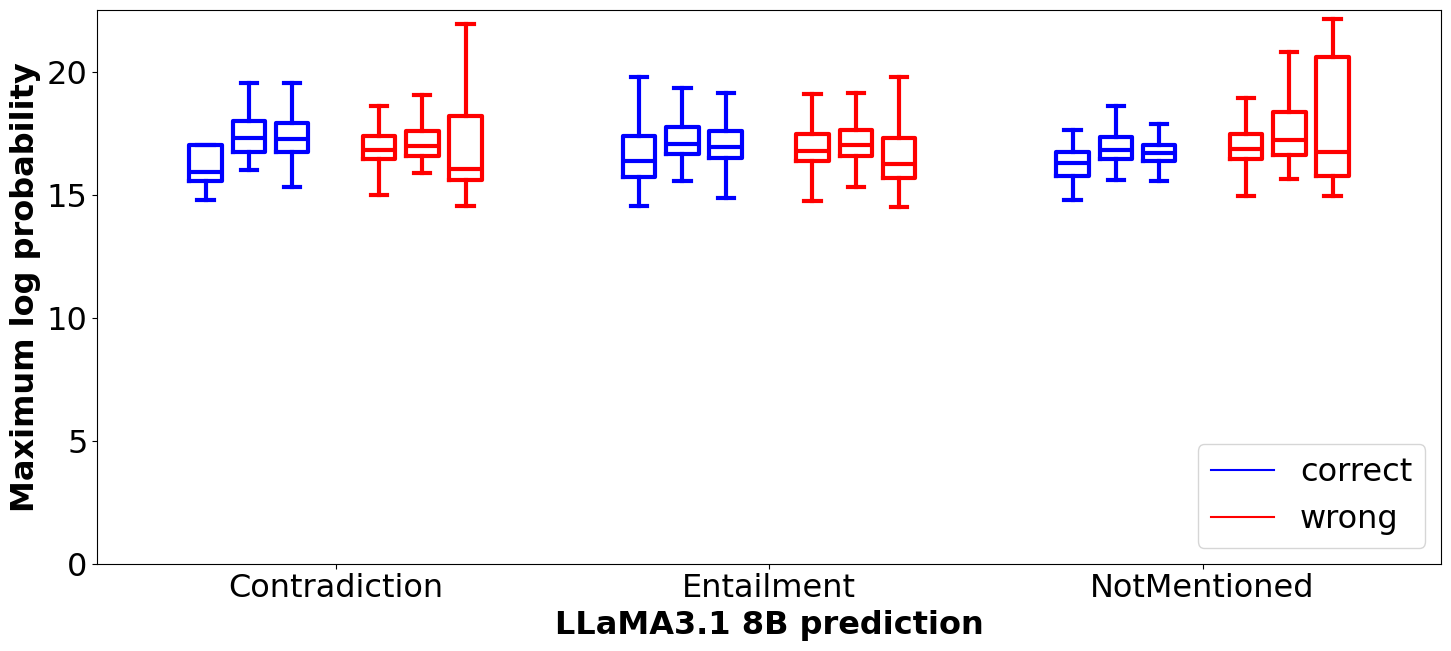

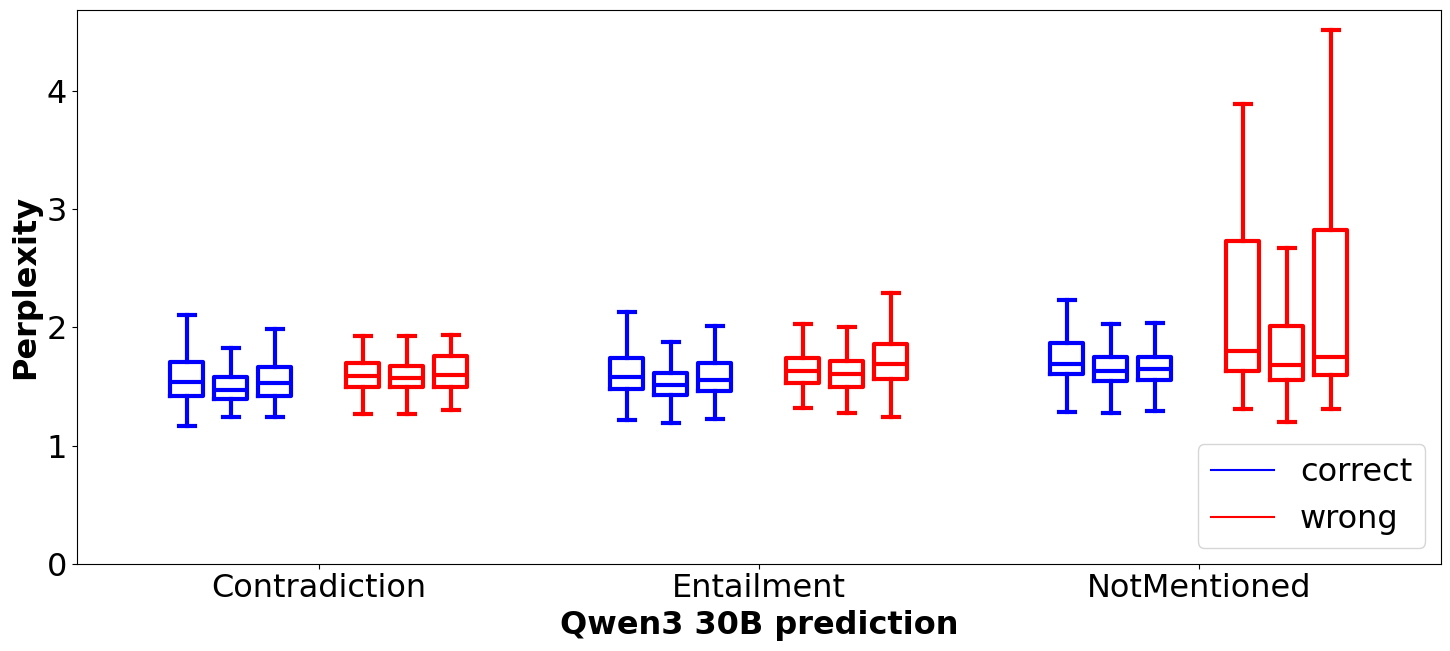

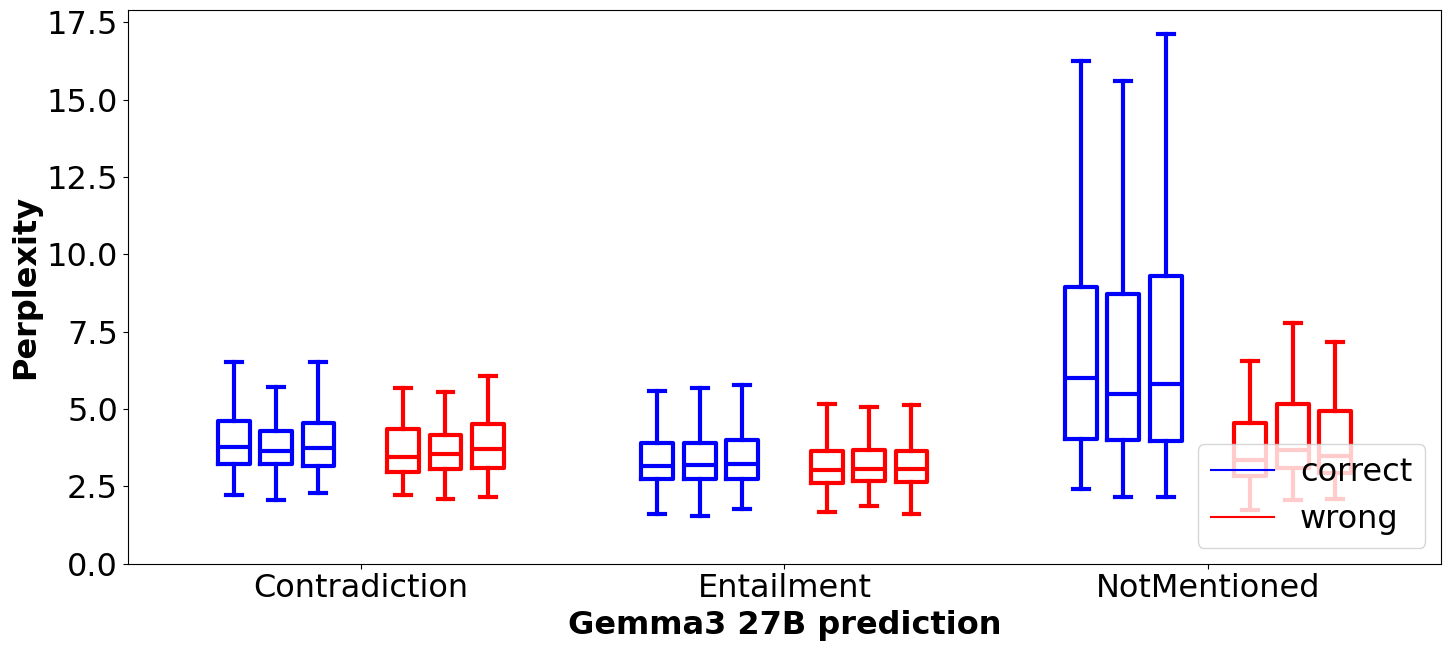

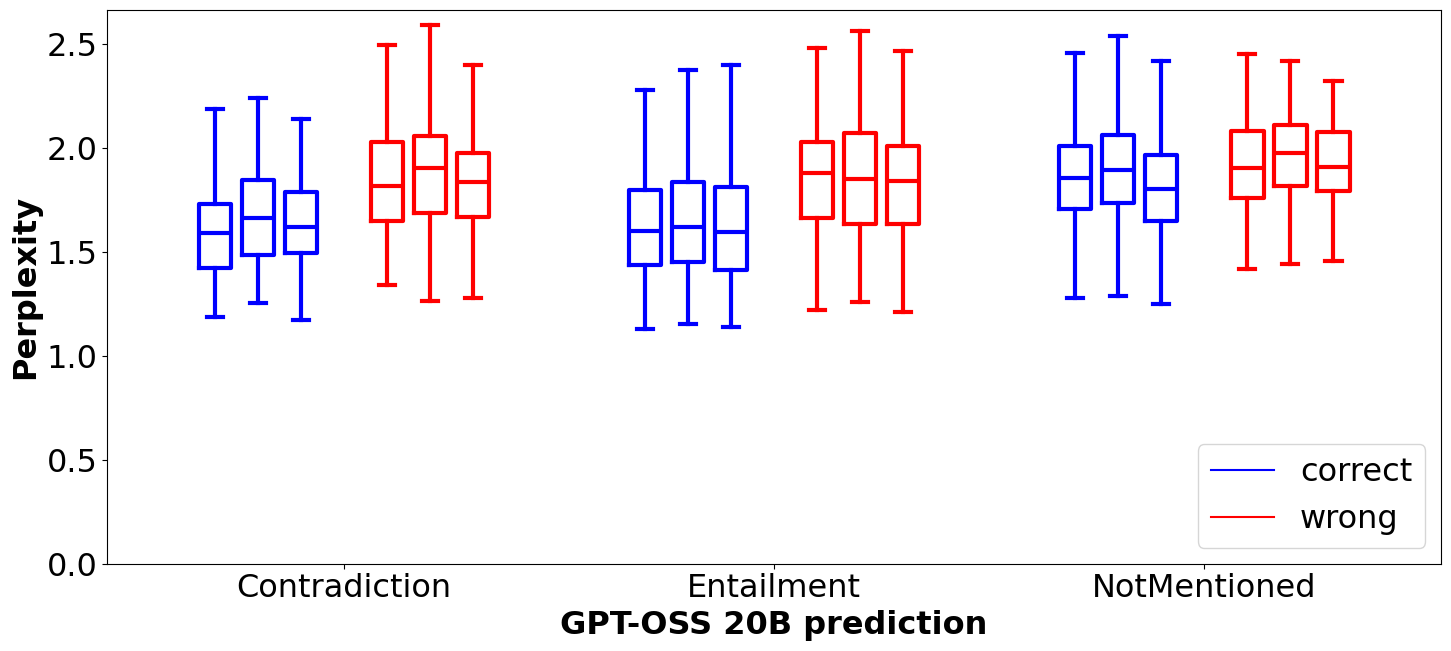

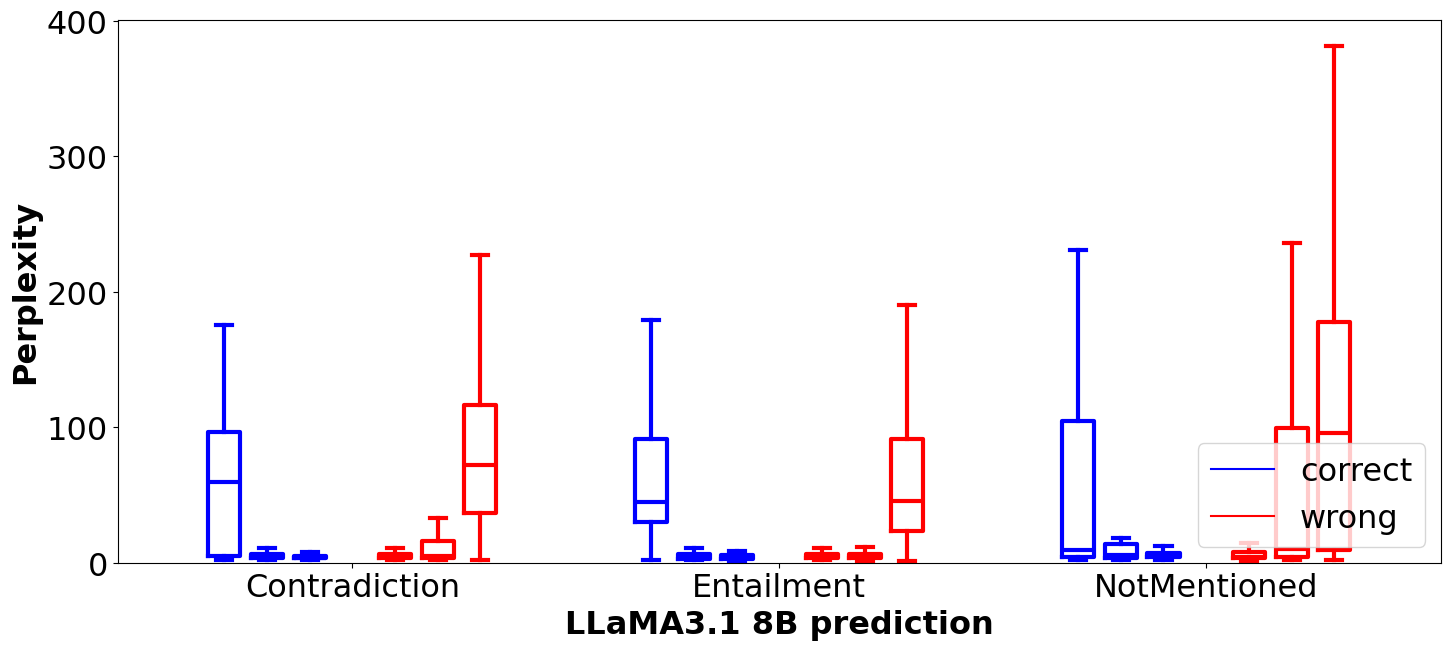

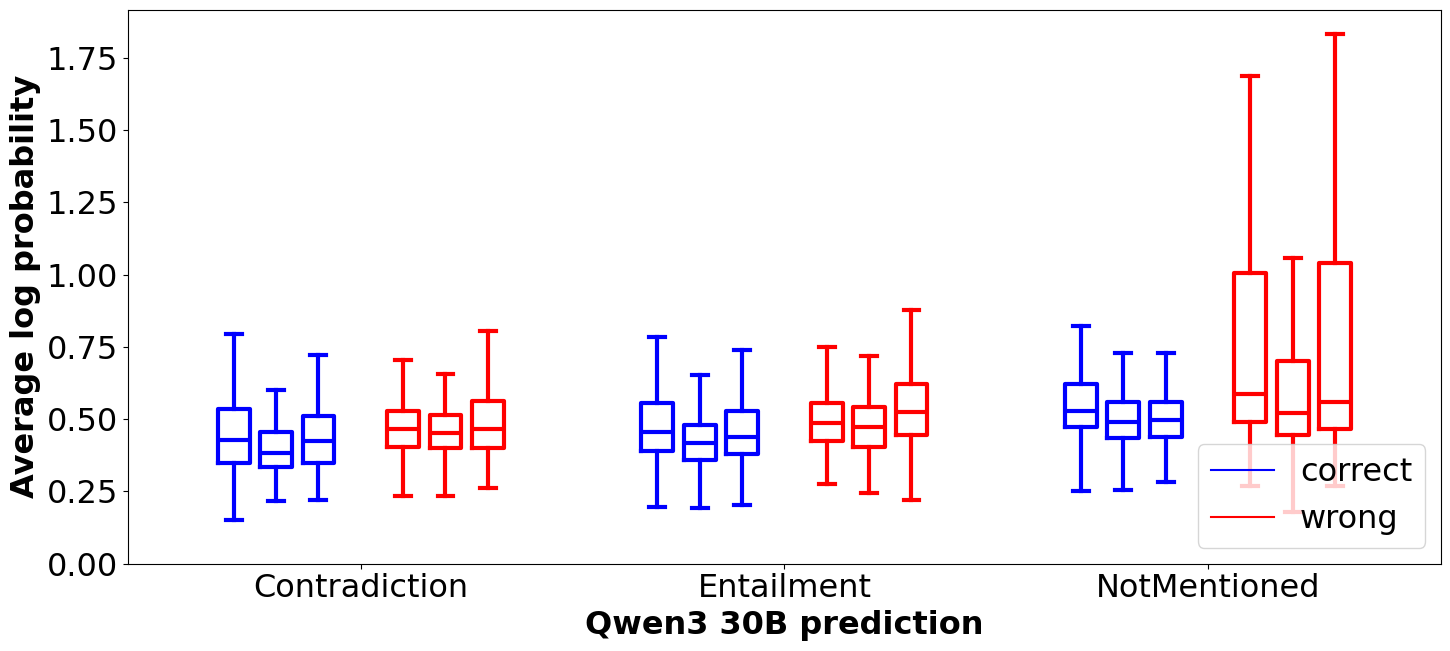

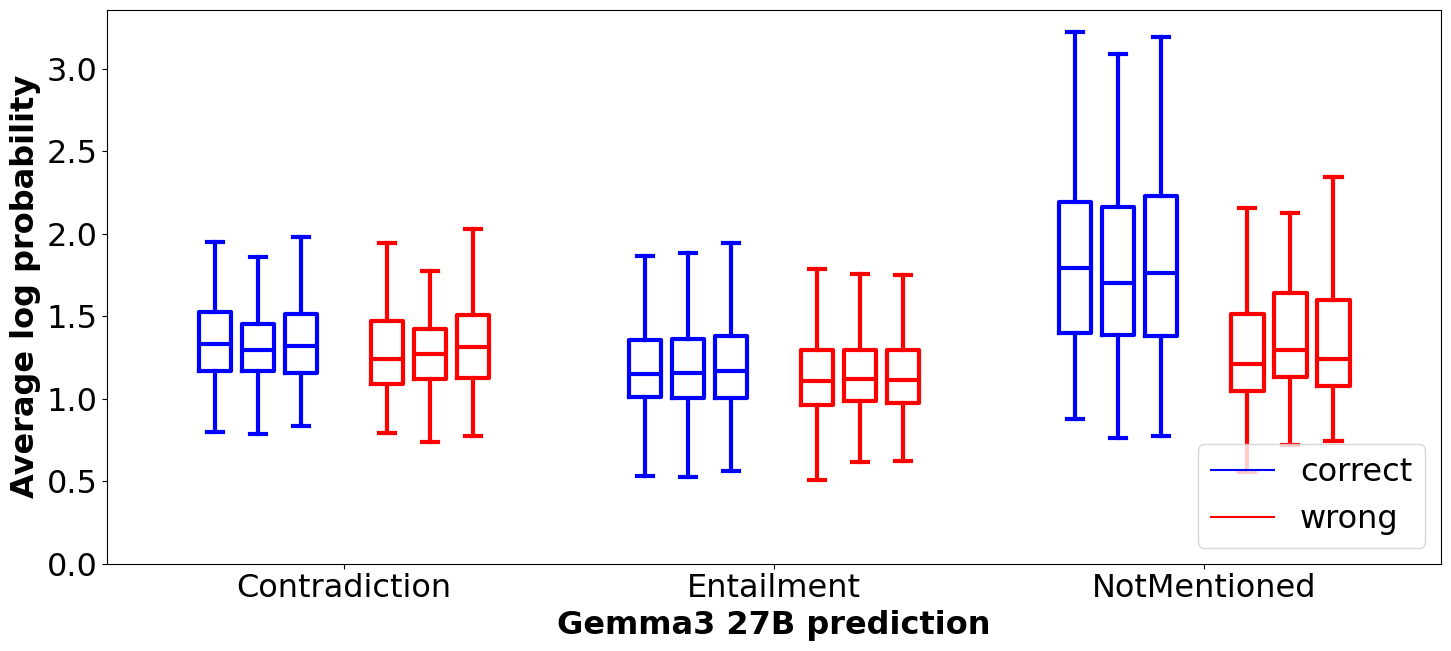

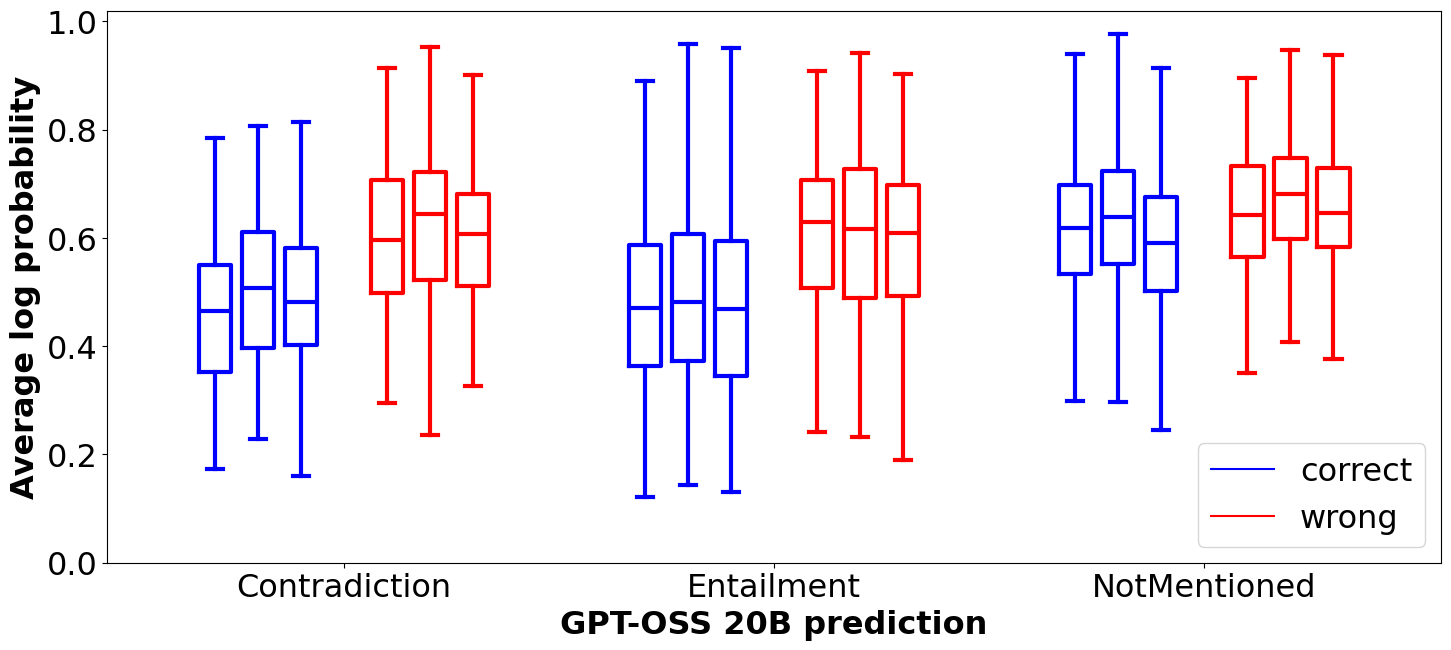

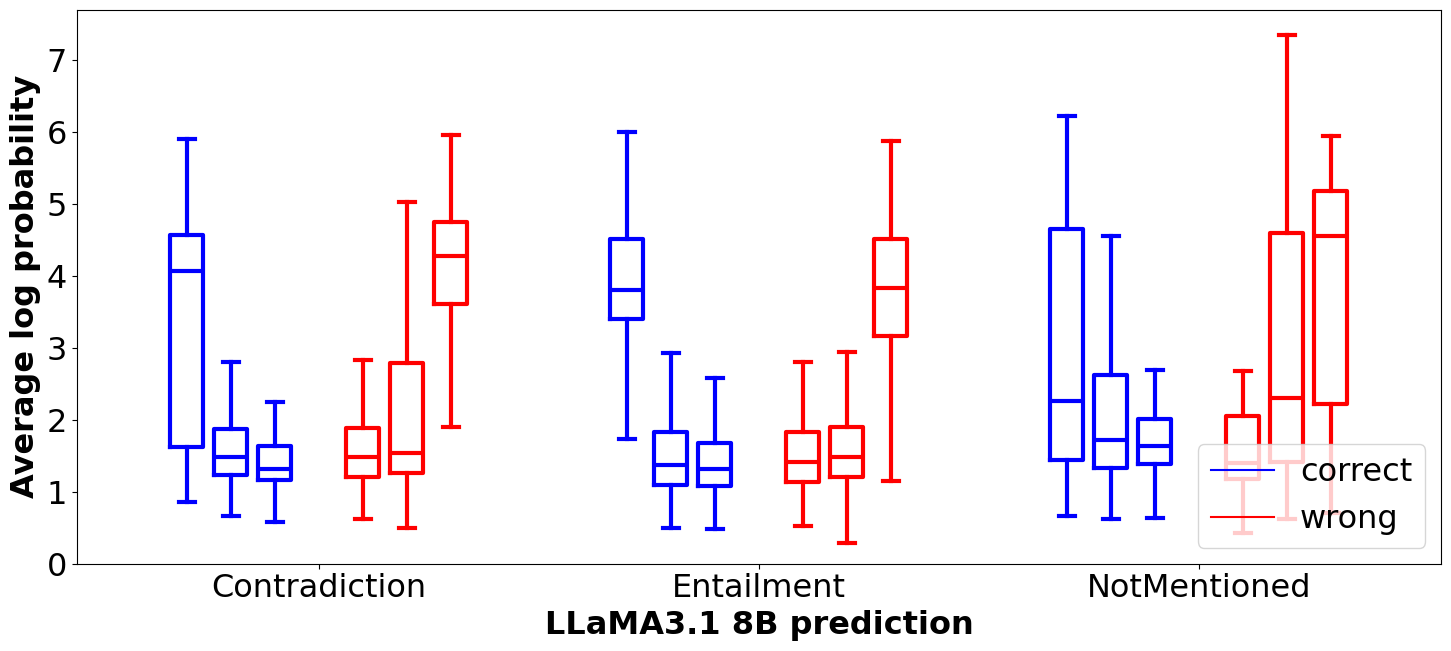

In [ ]:
def plot_seed_boxplots(data, figsize=(15,7)):
    """
    Parameters
    ----------
    data : dict
        {
            "model1": {
                "correct": {"label1": [...], "label2": [...], "label3": [...]},
                "wrong":   {"label1": [...], "label2": [...], "label3": [...]}
            },
            "model2": { ... }
        }
    """

    seeds = list(data.keys())
    labels = sorted(list(next(iter(data.values()))['correct'].keys()))

    num_labels = len(labels)
    box_width = 0.15
    pair_offset = [0.2, 0.4, 0.6]
    seed_gap = 1.0

    fig, ax = plt.subplots(figsize=figsize)

    x_positions = []
    x_labels = []
    seed_centers = []

    current_x = 0

    for label in labels:
        
        model_start = current_x
        
        correct_vals = []
        wrong_vals = []
        for seed in seeds:
            correct_vals.append(data[seed]['correct'][label])
            wrong_vals.append(data[seed]['wrong'][label])

        pos_correct = [current_x - po for po in pair_offset]
        pos_wrong = [current_x + po for po in pair_offset]
        x_positions.append(current_x)
        x_labels.append(label)
        current_x += 1

        model_end = current_x - 1
        seed_centers.append((model_start + model_end) / 2)
        current_x += seed_gap


        bp_correct = ax.boxplot(
            correct_vals,
            positions=pos_correct,
            widths=box_width,
            patch_artist=False,
            showfliers=False,
        )
        bp_wrong = ax.boxplot(
            wrong_vals,
            positions=pos_wrong,
            widths=box_width,
            patch_artist=False,
            showfliers=False
        )

        set_boxplot_line_color(bp_correct, 'blue', 3.)
        set_boxplot_line_color(bp_wrong, 'red', 3.)


    ax.set_xticks(x_positions)
    ax.set_xticklabels(labels)

    # Legend
    ax.plot([], [], color='blue', label='correct')
    ax.plot([], [], color='red', label='wrong')
    ax.legend()

    return fig, ax

for metric in ["maximum_logprob", "perplexity", "average_logprob"]:
    ylabels = {
        "maximum_logprob": "Maximum log probability", 
        "perplexity": "Perplexity",
        "average_logprob": "Average log probability"
    }
    ylabel = ylabels[metric]
    sorted_seed_responses = {}
    for model in by_seed.keys():
        for seed,seed_dict in by_seed[model].items():
            sorted_seed_responses[seed] = {}


            # sort correct/wrong properly, by class
            correct = {}
            wrong = {}
            for cw_dict, cw_str in [[correct, "correct"], [wrong, "wrong"]]:
                # build cw dict
                ld = seed_dict[cw_str]
                for label in ld.keys():
                    if label not in cw_dict:
                        cw_dict[label] = []
                    for el in ld[label]:
                        cw_dict[label] += [el["uncertainty"][metric]]

                # save cw dict
                sorted_seed_responses[seed][cw_str] = cw_dict

        fig, ax = plot_seed_boxplots(sorted_seed_responses)
        plt.rcParams.update({'font.size': 23})
        ax.set_ylim(bottom=0)
        ax.set_ylabel(ylabel, weight="bold")
        ax.legend(loc="lower right")
        ax.set_xlabel(f"{model} prediction", weight="bold")
        fig.tight_layout()
        fig.show()
        
        save_name = f"out/figs/config_1/by_seed/{model}_{metric}_by_seed.pdf"
        # fig.savefig(save_name)